<a href="https://colab.research.google.com/github/fadlanaprial/UPH/blob/main/01679250029_M_Fadlan_Aprial_Dalimunthe_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visual Analytics Lab: Linear Regression
**01679250029_M_Fadlan_Aprial_Dalimunthe**

Notebook ini berisi guided lab Climate Change dan mini assignment House Prices.
Jika dataset asli tidak tersedia, notebook membuat data sintetis agar semua code dapat dijalankan.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)


## 6.1 Load Dataset
**Pertanyaan:**
- Berapa jumlah observasi?
- Apa saja variabel numeriknya?
- Apakah terdapat missing values?
- Variabel mana yang menjadi predictor dan target?

**Jawaban:**
- Jumlah observasi: lihat output `df.shape`.
- Variabel numerik: `Year`, `CO2`, `Temperature`.
- Missing values: dicek dengan `df.isnull().sum()`.
- Predictor: `CO2` (simple), `CO2` dan `Year` (multiple). Target: `Temperature`.


In [2]:
# Load climate data
if os.path.exists("global_co2.csv"):
    df = pd.read_csv("global_co2.csv")
    print("Loaded global_co2.csv")
else:
    print("global_co2.csv not found. Creating synthetic climate data.")
    years = np.arange(1960, 2021)
    co2 = 317 + (years - 1960) * 1.6 + np.random.normal(0, 1.5, len(years))
    temp = -2.8 + 0.009 * co2 + np.random.normal(0, 0.05, len(years))
    df = pd.DataFrame({"Year": years, "CO2": co2, "Temperature": temp})

df.head()


global_co2.csv not found. Creating synthetic climate data.


,Year,CO2,Temperature
0,1960,317.745071,0.050423
1,1961,318.392604,0.010217
2,1962,321.171533,0.030733
3,1963,324.084545,0.157387
4,1964,323.048770,0.175251


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescribe:")
display(df.describe())
print("\nMissing values:")
print(df.isnull().sum())


Shape: (61, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         61 non-null     int64  
 1   CO2          61 non-null     float64
 2   Temperature  61 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.6 KB

Describe:


,Year,CO2,Temperature
count,61.000000,61.000000,61.000000
mean,1990.000000,364.760038,0.482955
std,17.752934,28.405098,0.261223
min,1960.000000,317.745071,0.010217
25%,1975.000000,340.156569,0.267646
50%,1990.000000,364.097440,0.480529
75%,2005.000000,387.920234,0.686842
max,2020.000000,412.863318,0.955321



Missing values:
Year           0
CO2            0
Temperature    0
dtype: int64


## 6.2 Data Quality
**Pertanyaan:** Variabel mana yang memiliki potential outliers?

**Jawaban:** Cek boxplot. Biasanya `Temperature` memiliki beberapa nilai ekstrem, sedangkan `Year` dan `CO2` mengikuti tren sehingga bukan outlier klasik.


Duplicated: 0


,count,mean,std,min,25%,50%,75%,max
Year,61.0,1990.000000,17.752934,1960.000000,1975.000000,1990.000000,2005.000000,2020.000000
CO2,61.0,364.760038,28.405098,317.745071,340.156569,364.097440,387.920234,412.863318
Temperature,61.0,0.482955,0.261223,0.010217,0.267646,0.480529,0.686842,0.955321


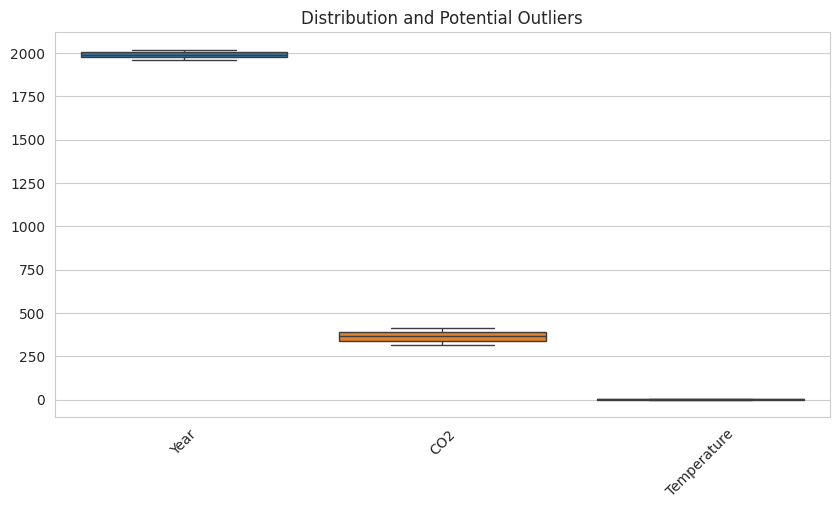

In [4]:
print("Duplicated:", df.duplicated().sum())
display(df.describe().T)

plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.title("Distribution and Potential Outliers")
plt.xticks(rotation=45)
plt.show()


## 6.3 Distribution & Time Series
**Pertanyaan:**
- Apa pola utama pada kedua time series?
- Apakah kedua variabel menunjukkan pola temporal yang serupa?

**Jawaban:** CO2 meningkat monoton. Temperature juga meningkat tetapi fluktuatif. Keduanya sama-sama naik, terutama setelah 1980-an.


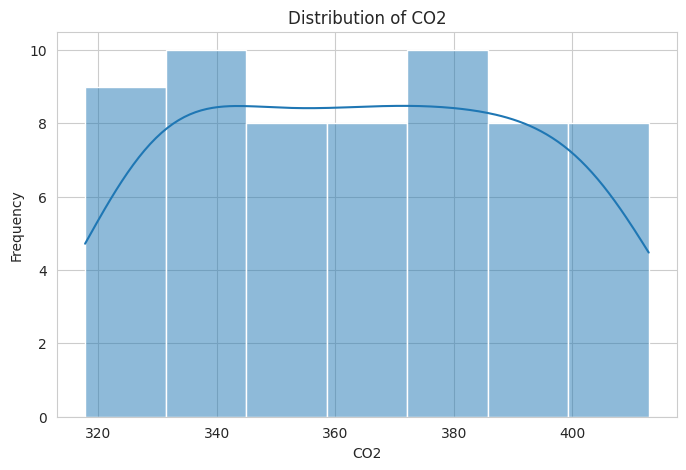

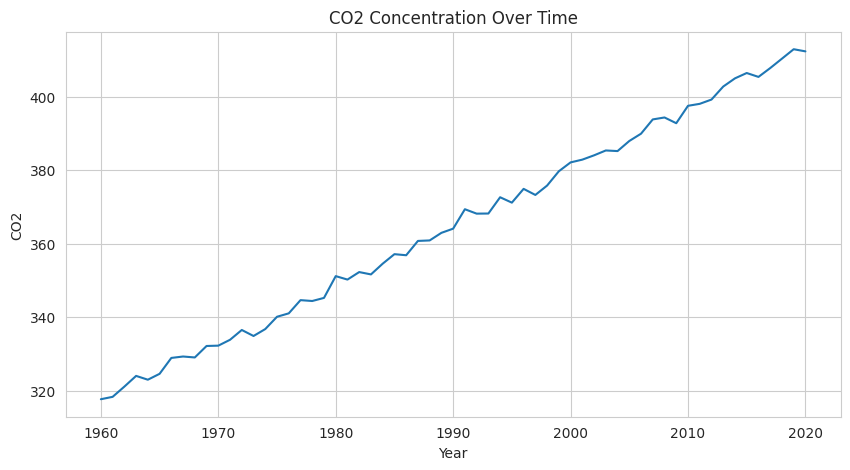

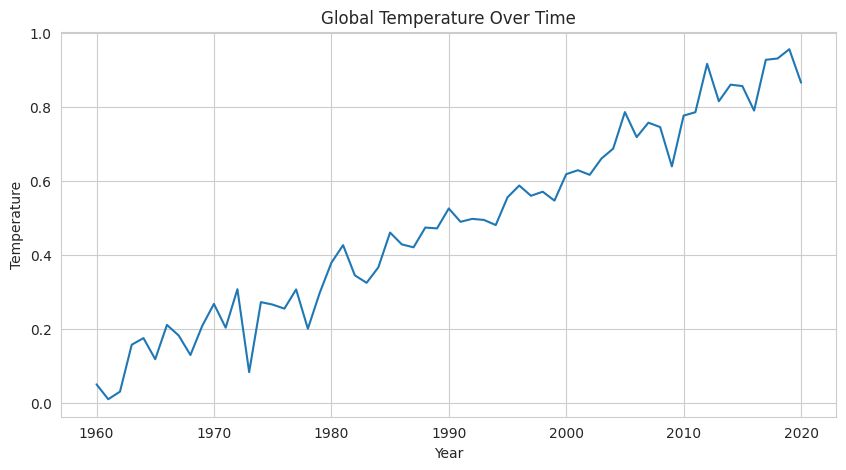

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["CO2"], kde=True)
plt.title("Distribution of CO2")
plt.xlabel("CO2")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Year"], df["CO2"])
plt.xlabel("Year")
plt.ylabel("CO2")
plt.title("CO2 Concentration Over Time")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Year"], df["Temperature"])
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.title("Global Temperature Over Time")
plt.show()


## 6.4 Scatter Plot
**Pertanyaan:**
- Apakah hubungan terlihat linear?
- Positif atau negatif?
- Ada observasi jauh dari pola utama?
- Apakah mendukung Linear Regression?

**Jawaban:** Hubungan linear positif. Beberapa titik ekstrem mungkin ada. Scatter plot mendukung linear regression.


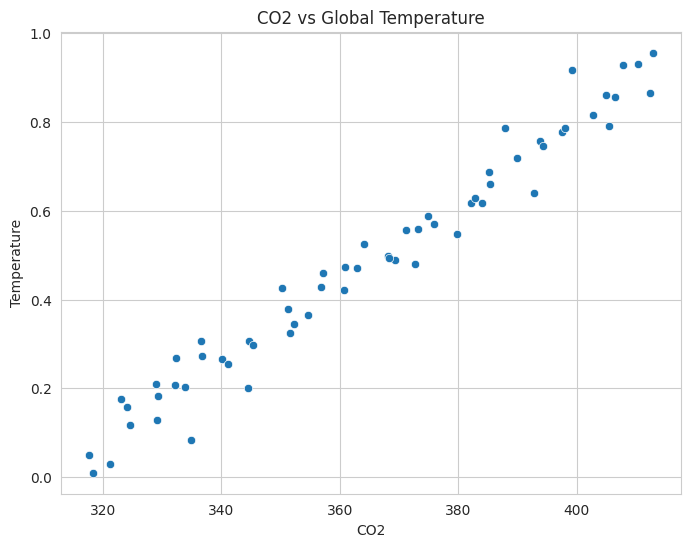

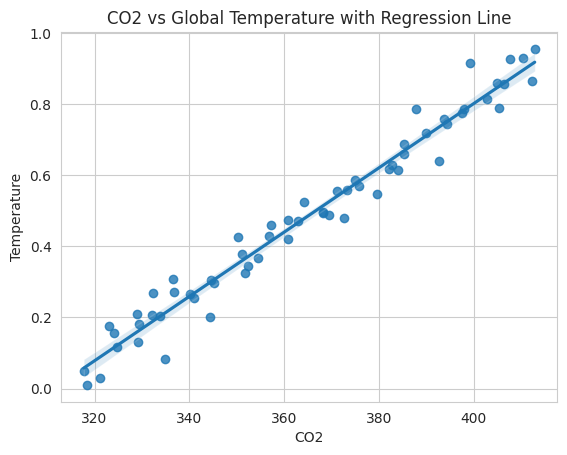

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="CO2", y="Temperature")
plt.title("CO2 vs Global Temperature")
plt.xlabel("CO2")
plt.ylabel("Temperature")
plt.show()

sns.regplot(data=df, x="CO2", y="Temperature")
plt.title("CO2 vs Global Temperature with Regression Line")
plt.show()


## 6.5 Correlation
**Pertanyaan:**
- Apakah correlation mendukung scatter plot?
- Apakah correlation tinggi berarti causal?

**Jawaban:** Ya, korelasi positif tinggi. Tidak, korelasi tinggi bukan bukti kausalitas.


,Year,CO2,Temperature
Year,1.000000,0.998866,0.981012
CO2,0.998866,1.000000,0.983471
Temperature,0.981012,0.983471,1.000000


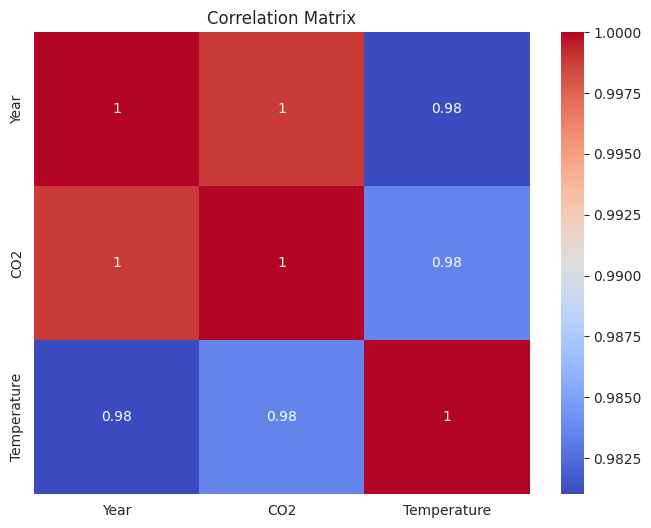

In [7]:
display(df.corr(numeric_only=True))

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## 6.6 Simple Linear Regression
**Pertanyaan:**
- Apa arti coefficient CO2?
- Bagaimana menjelaskan intercept?

**Jawaban:** Coefficient CO2 = perubahan Temperature per 1 ppm CO2. Intercept = prediksi Temperature saat CO2 = 0 (tidak realistis secara fisik, hanya baseline matematis).


In [8]:
X = df[["CO2"]]
y = df["Temperature"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficient CO2:", model.coef_[0])


Intercept: -2.8076402171013246
Coefficient CO2: 0.009037290132842822


## 6.7 Prediction & Evaluation
**Pertanyaan:**
- Apa arti MAE?
- Mengapa RMSE lebih sensitif terhadap error besar?
- Apa interpretasi R²?

**Jawaban:** MAE = rata-rata error absolut. RMSE memberi bobot lebih pada error besar karena dikuadratkan. R² = proporsi variansi target yang dijelaskan model.


In [9]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
display(result.head(10))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


,Actual,Predicted
0,0.050423,0.063914
1,0.118239,0.126305
2,0.717910,0.716081
3,0.489303,0.530540
4,0.083383,0.219220
5,0.855837,0.865087
6,0.480529,0.559960
7,0.638860,0.741805
8,0.307299,0.233977
9,0.617937,0.645578


MAE: 0.04388998327887929
RMSE: 0.05923059218440796
R2: 0.9552528389197803


## 6.8 Actual vs Predicted
**Pertanyaan:**
- Apa arti jarak titik dari diagonal?
- Apakah ada prediksi yang jauh dari aktual?

**Jawaban:** Jarak dari diagonal = error. Prediksi jauh dari diagonal berarti model kurang akurat pada titik tersebut.


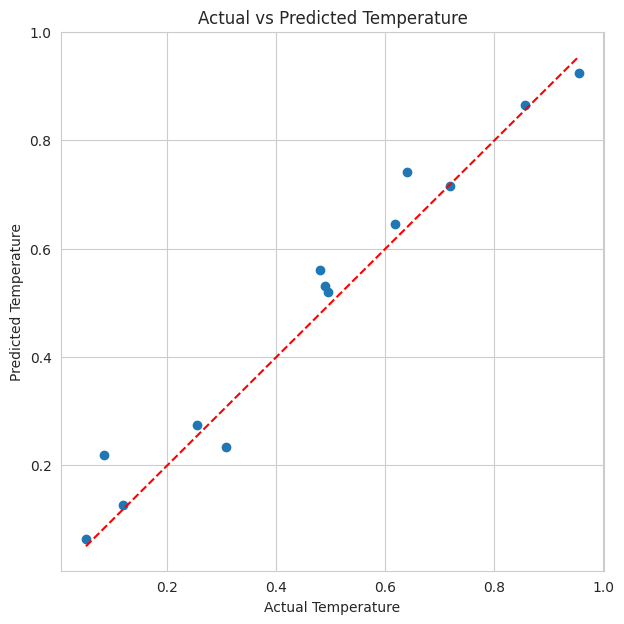

In [10]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--", color="red")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()


## 6.9 Residual Analysis
**Pertanyaan:**
- Apakah residual random?
- Apakah ada pola?
- Apakah ada outlier atau perubahan variance?

**Jawaban:** Residual idealnya random di sekitar 0. Pola tertentu menandakan model kurang tepat. Outlier terlihat dari residual besar. Perubahan variance terlihat dari pola corong.


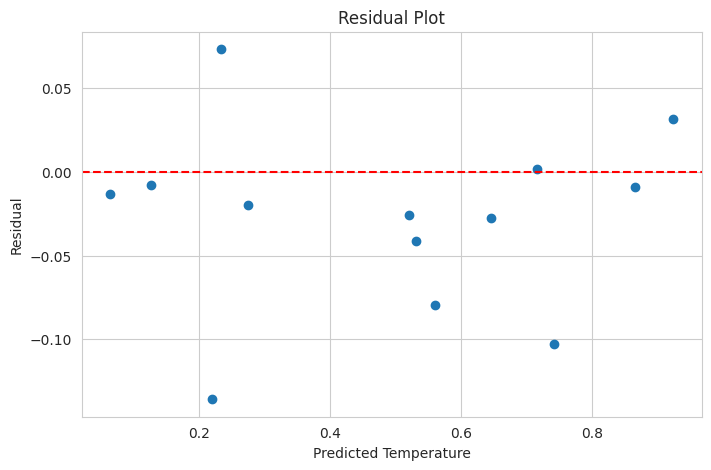

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--", color="red")
plt.xlabel("Predicted Temperature")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


## 6.10 Multiple Linear Regression
**Pertanyaan:**
- Mengapa penambahan Year mengubah model?
- Apakah R² lebih tinggi selalu lebih baik?
- Apa masalah jika predictor memiliki tren waktu kuat?

**Jawaban:** Year menambah informasi temporal. R² lebih tinggi tidak selalu lebih baik karena bisa overfitting/multikolinearitas. Tren waktu kuat dapat menyebabkan multikolinearitas dan coefficient tidak stabil.


In [12]:
X = df[["CO2", "Year"]]
y = df["Temperature"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
mae_multi = mean_absolute_error(y_test, y_pred_multi)

print("Multiple Regression")
print("Intercept:", model_multi.intercept_)
print("Coefficients:", model_multi.coef_)
print("MAE:", mae_multi)
print("RMSE:", rmse_multi)
print("R2:", r2_multi)


Multiple Regression
Intercept: 2.68923398848073
Coefficients: [ 0.01099369 -0.0031208 ]
MAE: 0.04373377145947559
RMSE: 0.05820511995345992
R2: 0.9567888608917829


# Mini Assignment: Predicting House Prices

Dataset housing sintetis dibuat jika tidak ada file. Target: `price`. Predictor: `area`, `bedrooms`, `bathrooms`.


In [13]:
# Housing data
if os.path.exists("housing.csv"):
    df_h = pd.read_csv("housing.csv")
    print("Loaded housing.csv")
else:
    print("housing.csv not found. Creating synthetic housing data.")
    n = 300
    area = np.random.randint(500, 5000, n)
    bedrooms = np.random.randint(1, 7, n)
    bathrooms = np.random.randint(1, 5, n)
    price = 50000 + 100 * area + 10000 * bedrooms + 15000 * bathrooms + np.random.normal(0, 20000, n)
    df_h = pd.DataFrame({
        "area": area,
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "price": price
    })

df_h.head()


housing.csv not found. Creating synthetic housing data.


,area,bedrooms,bathrooms,price
0,2827,1,3,379151.841151
1,3431,5,2,462047.084533
2,697,6,4,258977.006374
3,2430,6,2,402471.148950
4,4082,5,1,550918.066426


## Task 1 – Data Understanding
- Target: `price`.
- Predictor: `area`, `bedrooms`, `bathrooms`.
- Cek jumlah observasi, tipe data, missing values, outlier.
- Tampilkan `df.info()` dan `df.describe()`.
- Buat minimal satu visualisasi distribusi.


Shape: (300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       300 non-null    int64  
 1   bedrooms   300 non-null    int64  
 2   bathrooms  300 non-null    int64  
 3   price      300 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 9.5 KB


,area,bedrooms,bathrooms,price
count,300.000000,300.000000,300.000000,300.000000
mean,2827.883333,3.506667,2.460000,403476.628584
std,1276.655621,1.747417,1.088892,131091.503717
min,504.000000,1.000000,1.000000,127033.697001
25%,1649.500000,2.000000,2.000000,295993.222584
50%,2987.000000,4.000000,2.000000,413432.666399
75%,3849.500000,5.000000,3.000000,506683.398595
max,4999.000000,6.000000,4.000000,696000.547073


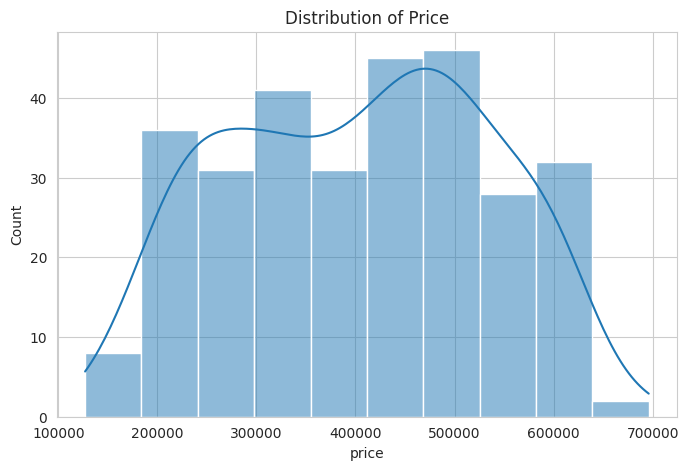

In [14]:
print("Shape:", df_h.shape)
df_h.info()
display(df_h.describe())

plt.figure(figsize=(8,5))
sns.histplot(df_h["price"], kde=True)
plt.title("Distribution of Price")
plt.show()


## Task 2 – Visual Analytics
- Distribution plot target.
- Scatter plot Area vs Price.
- Correlation heatmap.
- Tulis minimal tiga visual insights.


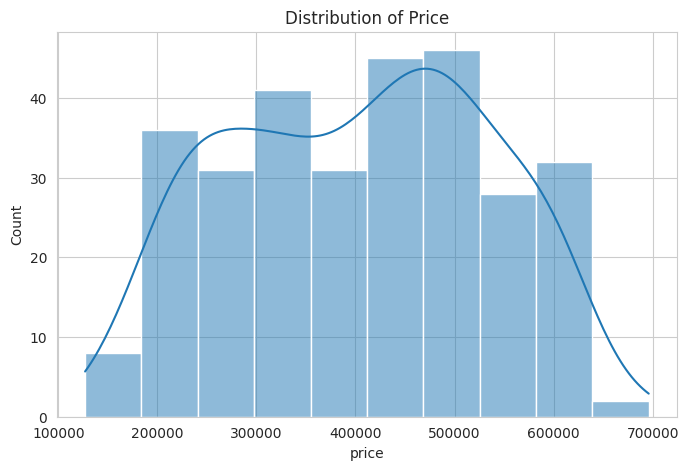

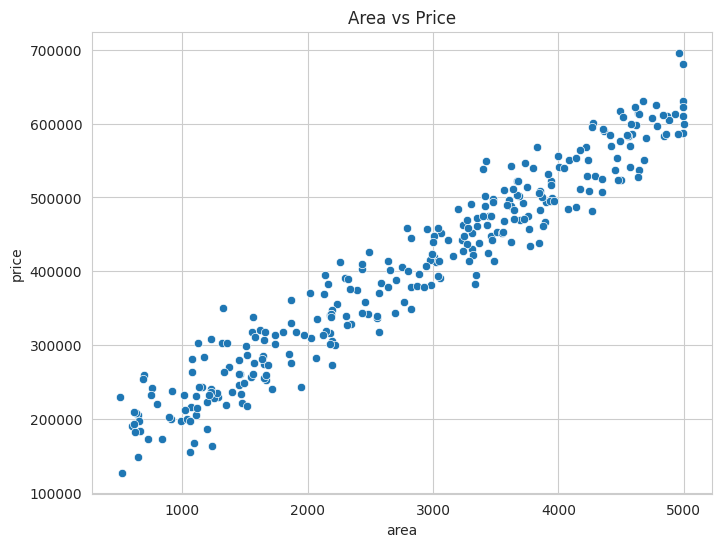

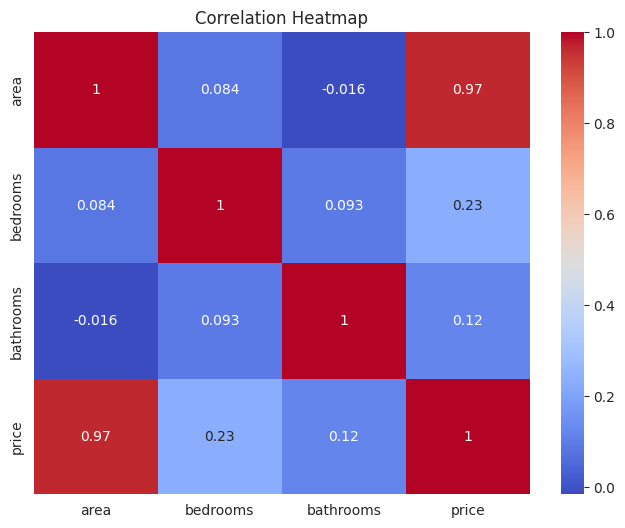

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df_h["price"], kde=True)
plt.title("Distribution of Price")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_h, x="area", y="price")
plt.title("Area vs Price")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df_h.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


**Insights:**
1. Harga rumah cenderung right-skewed.
2. Area berkorelasi positif kuat dengan harga.
3. Bedrooms dan bathrooms berkorelasi lebih lemah dibanding area.


## Task 3 – Simple Linear Regression
Bangun `Price = β0 + β1 Area`. Hitung MAE, RMSE, R². Interpretasikan coefficient Area.


In [16]:
X = df_h[["area"]]
y = df_h["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

print("Intercept:", model_simple.intercept_)
print("Coefficient Area:", model_simple.coef_[0])
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_simple)))
print("R2:", r2_score(y_test, y_pred_simple))


Intercept: 125541.17927891586
Coefficient Area: 98.63618265565353
MAE: 24100.95485348118
RMSE: 30926.312891358364
R2: 0.9450760014940494


**Interpretasi:** Setiap penambahan 1 satuan area diprediksi menaikkan harga sebesar coefficient Area.


## Task 4 – Multiple Linear Regression
Bangun model dengan `area`, `bedrooms`, `bathrooms`. Bandingkan dengan simple regression.


In [17]:
X = df_h[["area", "bedrooms", "bathrooms"]]
y = df_h["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_multi_h = LinearRegression()
model_multi_h.fit(X_train, y_train)

y_pred_multi_h = model_multi_h.predict(X_test)

print("Intercept:", model_multi_h.intercept_)
print("Coefficients:", model_multi_h.coef_)
print("MAE:", mean_absolute_error(y_test, y_pred_multi_h))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi_h)))
print("R2:", r2_score(y_test, y_pred_multi_h))


Intercept: 53207.559999390214
Coefficients: [   97.93443714 10602.47583544 14587.89060955]
MAE: 14283.784042321104
RMSE: 18115.17047483041
R2: 0.9811552358493921


**Perbandingan:** Multiple regression biasanya memiliki R² lebih tinggi dan RMSE lebih rendah, tetapi peningkatannya bisa kecil.


## Task 5 – Visual Model Evaluation
Buat Actual vs Predicted dan Residual plot. Identifikasi prediksi terburuk.


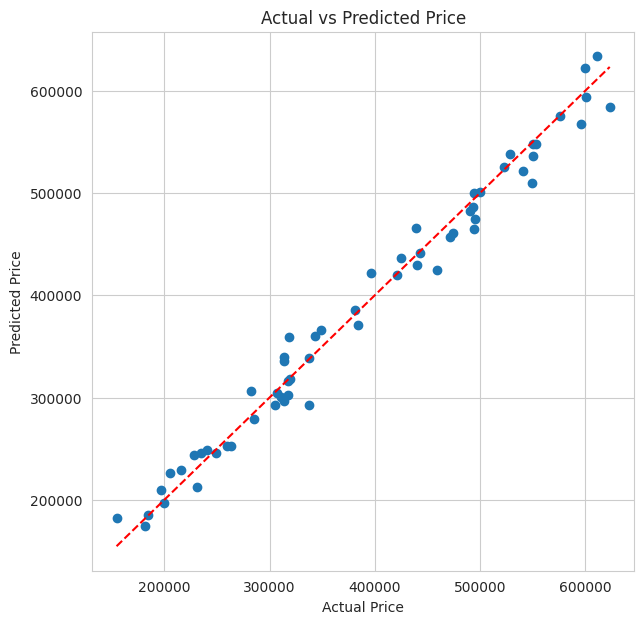

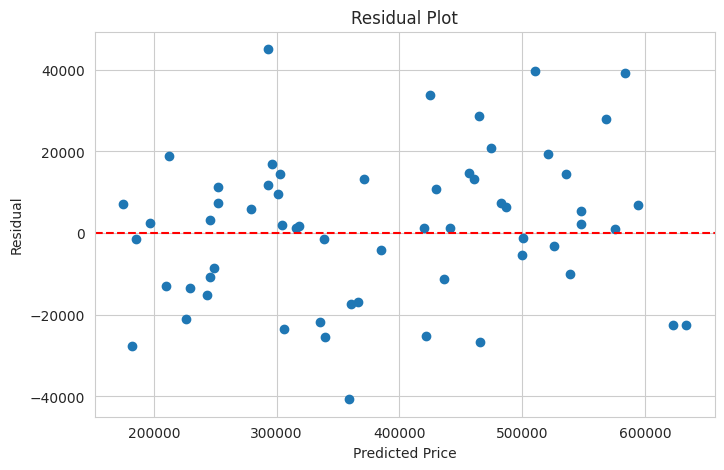

In [18]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_multi_h)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--", color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

residuals_h = y_test - y_pred_multi_h

plt.figure(figsize=(8,5))
plt.scatter(y_pred_multi_h, residuals_h)
plt.axhline(y=0, linestyle="--", color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


**Prediksi terburuk:** Biasanya rumah dengan harga/area ekstrem atau kombinasi fitur tidak umum. Penyebab: outlier, variabel penting tidak dimasukkan, atau asumsi linear tidak terpenuhi.


## Task 6 – Analytical Interpretation
- Apakah model kedua menghasilkan pola berbeda?
- Apakah visualisasi mendukung hasil numerik?
- Sebutkan minimal tiga keterbatasan model.
- Tuliskan rekomendasi analisis lanjutan.

**Jawaban:**
- Model kedua bisa sedikit berbeda, terutama pada rumah besar.
- Visualisasi umumnya mendukung hasil numerik.
- Keterbatasan: hanya 3 predictor, rentan outlier, asumsi linearitas, potensi multikolinearitas.
- Rekomendasi: tambah fitur lokasi/kualitas, transformasi, regularisasi, cross-validation.


## Model Comparison Template

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Simple Linear Regression | (0.04388998327887929) | (0.05923059218440796) | (0.9552528389197803) |
| Multiple Linear Regression | (24100.95485348118) | (18115.17047483041) | (0.9811552358493921) |
